In [37]:
#Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 52 - Análisis de regresión")

In [116]:
#Se lee la base de datos y se convierte en dataframe
data_house = pd.read_csv("kc_house_data.csv")
data_house

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [117]:
#Limpieza de datos

#Se eliminan del dataframe las variables de id y zipcode. Ya que estas no son características directas con la casa
data_house = data_house.drop(columns=['id', 'zipcode'])

#Se toma el año de venta de la columna date, se convierte a int despues
data_house['date'] = data_house['date'].str[:4]
data_house['date'] = data_house['date'].astype(int)

#Se crea columna de antiguedad de la casa
data_house["yr_antique"] = data_house["date"] - data_house["yr_built"]

#Se eliminan las columnas de "date" y "yr_built"
data_house = data_house.drop(columns = ["date", "yr_built"])

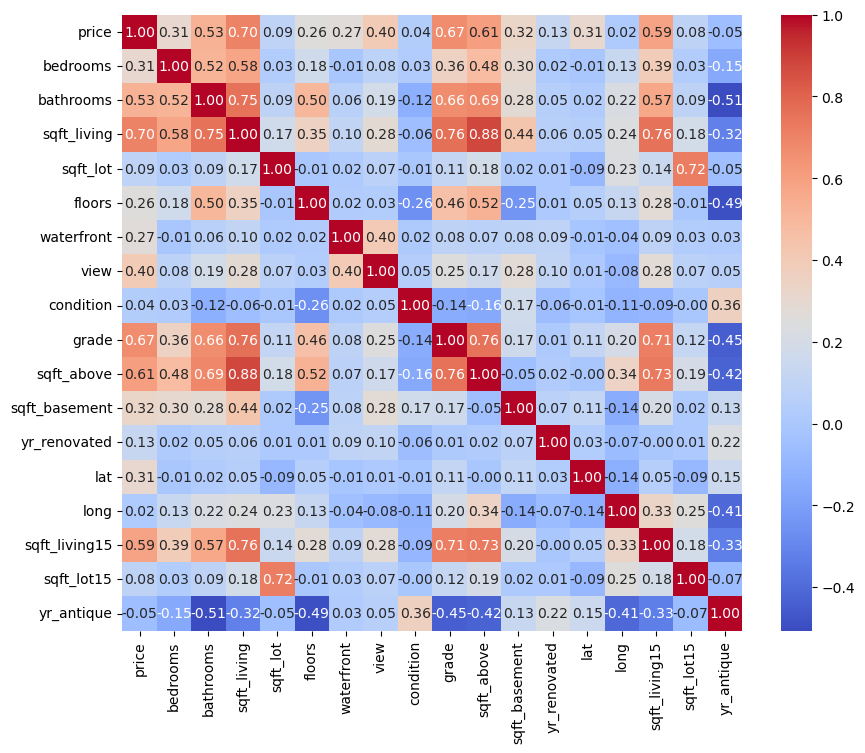

In [118]:
#Análisis de correlaciones entre las variables para identificar colinealidad
corr = data_house.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

In [119]:
#Se eliminan las variables que pueden representar problemas de colinealidad(sqft_living15, sqft_lot15, grade, bathrooms y sqft_above)
data_house = data_house.drop(columns=['sqft_living15', 'sqft_lot15', 'grade', 'sqft_above', 'bathrooms'])

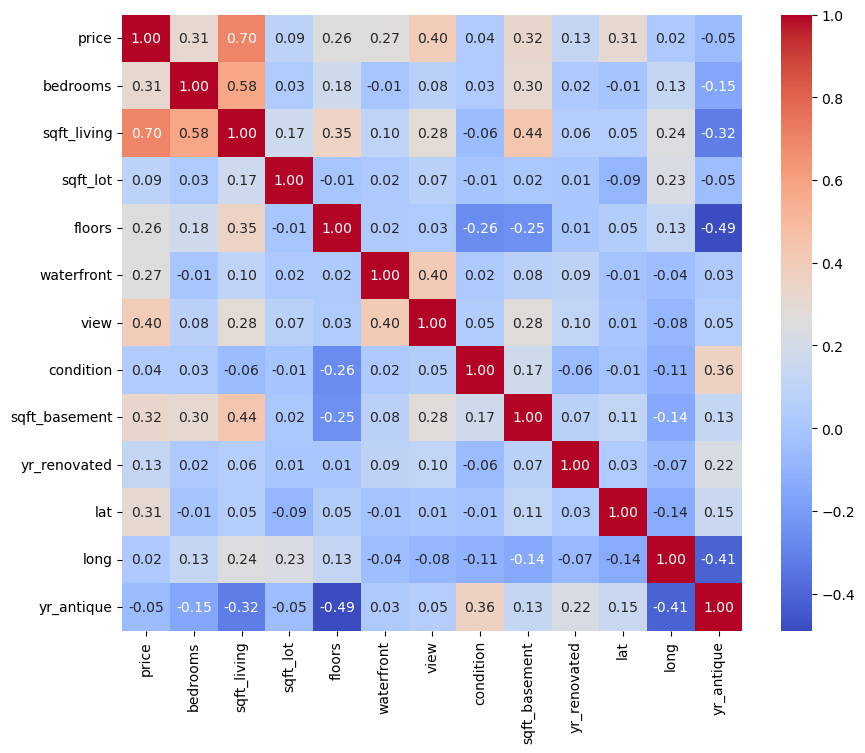

In [120]:
#Análisis de correlaciones entre las variables para identificar si aún existe colinealidad
corr = data_house.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

In [121]:
#Agregando la variable de 1 para el intercepto
data_house.insert(0, 'Intercepto', 1)

In [122]:
#Definiendo las matrices
Xdata = data_house[["Intercepto", "bedrooms", "sqft_living", "sqft_lot", "floors", "waterfront", 
                    "view", "condition", "sqft_basement", "yr_renovated", "yr_antique", "lat", "long"]].values
Ydata = data_house[["price"]].values

In [123]:
#Dividir en bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(Xdata, Ydata, test_size = 0.3, random_state = 1)

x = x_train
y = y_train

In [124]:
#Opción de formato numérico para evitar que se coloquen decimales con notación científica
np.set_printoptions(formatter={"float_kind":"{:f}".format})

In [125]:
#Reporte automatizada de la regresión en python
import statsmodels.api as sm

regressor = sm.OLS(y, x). fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     2441.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:21:32   Log-Likelihood:            -2.0664e+05
No. Observations:               15129   AIC:                         4.133e+05
Df Residuals:                   15116   BIC:                         4.134e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.196e+07   1.81e+06    -28.741      0.0

In [126]:
#Proceso de modelo de regresión múltiple mediante matrices

#Operaciones para obtener la matriz b
XT_X = np.matmul(np.matrix.transpose(x), x)
XT_X_inv = np.linalg.inv(XT_X)

XT_Y = np.matmul(np.matrix.transpose(x), y)
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-51956226.332031],
       [-38351.281993],
       [300.749265],
       [-0.087578],
       [25908.694079],
       [533252.631496],
       [64734.498883],
       [35613.806817],
       [-70.389190],
       [32.992305],
       [1225.944119],
       [674367.818583],
       [-161296.067377]])

In [127]:
#Cálculo de TSS (Suma Total de Cuadrados)
TSS = np.matmul(np.matrix.transpose(y), y) - len(y) * (y.mean()**2)

#Cálculo del ESS (Suma Explicada de Cuadrados)
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(x)), np.matmul(x,betas)) - len(y) * (y.mean()**2)

#Cálculo de RSS (Residuales al Cuadrado)
RSS = TSS - ESS

#Cálculo del Coeficiente de Determinación R cuadrdada
RSq = 1 - RSS / TSS
print("Coeficiente de determinación R cuadrada = ", RSq)

#Cálculo del Coeficiente de Determinación R cuadrada ajustada
RSqAj = 1 - (RSS / (x.shape[0] - x.shape[1])) / (TSS / (x.shape[0] - 1))
print("Coeficiente de determinación R cuadrada ajustada = ", RSqAj)

Coeficiente de determinación R cuadrada =  [[0.659587]]
Coeficiente de determinación R cuadrada ajustada =  [[0.659317]]


array([[<Axes: title={'center': '0'}>]], dtype=object)

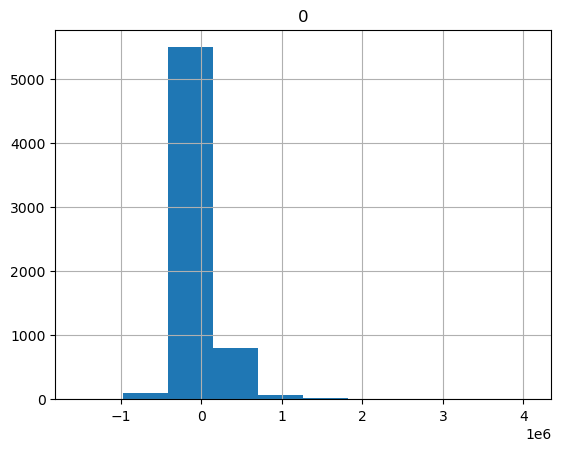

In [128]:
#Aplicación sobre la base de prueba
y_pred = np.matmul(x_test, betas)

#Cálculo de residuales
Resid = y_test - y_pred

#Gráfico del histograma de residuales para la base de prueba
df = pd.DataFrame(Resid)
df.hist()

In [129]:
from sklearn.metrics import r2_score
from sklearn import metrics

print("Coeficiente R cuadrado", r2_score(y_test, y_pred))

Coeficiente R cuadrado 0.6483890669904986
